In [1]:
from pathlib import Path
import sys

import torch
import numpy as np
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.datasets import TUDataset

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import pytorch_to_networkx, networkx_to_igraph, DatasetPT
from src.graph_analysis import count_deg_moments, calculate_annd, calculate_annd_error
from src.generate_datasets import generate_graph
from notebooks.visualization_utils import plot_graph, plot_annd

In [2]:
DATASET = "BZR"
METHOD = "anndg"  # Options: "padma", "anndg", etc.
IDX = 84

try:
    dataset = DatasetPT(PROJECT_ROOT / "data" / DATASET / f"{DATASET}_original.pt")
except:
    dataset = TUDataset(PROJECT_ROOT / "data", name=DATASET)

GRAPH = pytorch_to_networkx(dataset[IDX])

Original Graph Assortativity: -0.2862


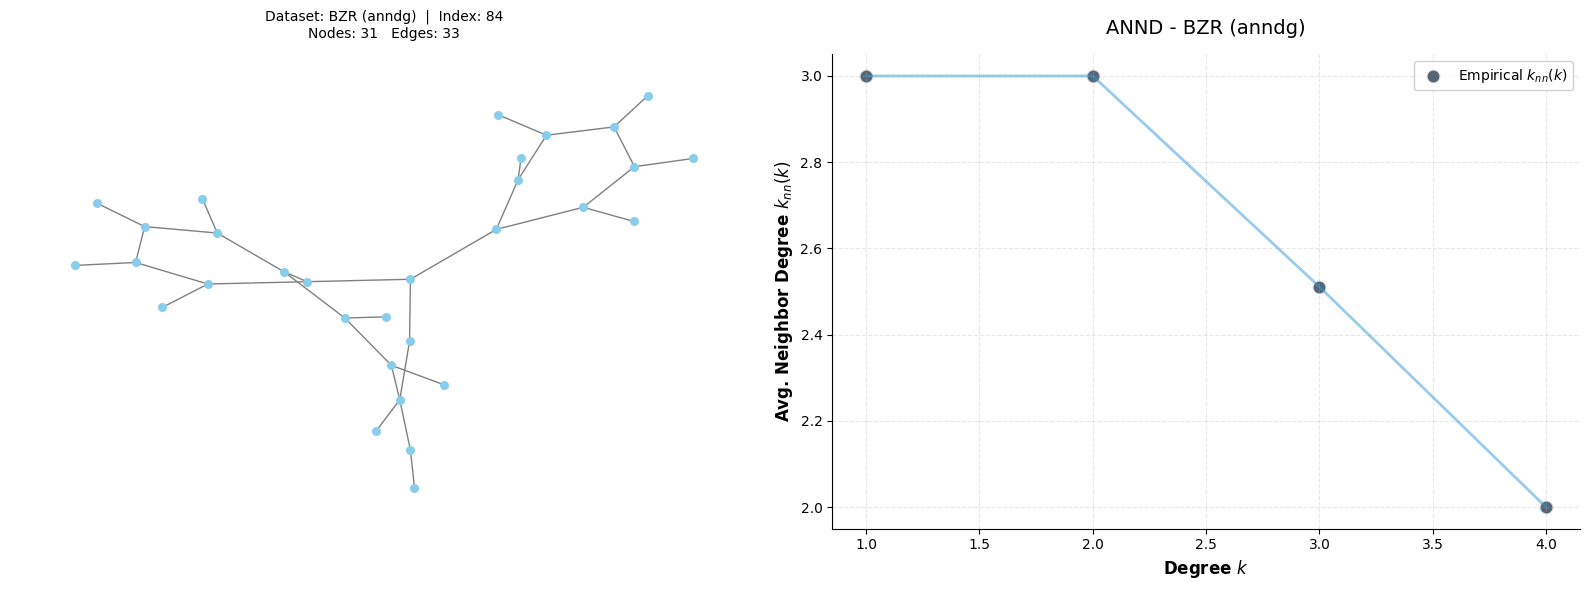

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_graph(graph=GRAPH, ax=ax1, dataset_name=f"{DATASET} ({METHOD})", graph_index=IDX)
plot_annd(graph=GRAPH, ax=ax2, title=f"ANND - {DATASET} ({METHOD})")

# Calculate and print assortativity
assortativity = nx.degree_assortativity_coefficient(GRAPH)
print(f"Original Graph Assortativity: {assortativity:.4f}")

plt.tight_layout()
plt.show()

Degree distribution:                     [0.35483871 0.12903226 0.41935484 0.06451613]
Initial ANND:                            [2.54545455 2.875      2.71794872 2.375     ]
Target ANND (adapted):                   [3.         3.         2.51111111 2.        ]
Initial ANND error:                      0.319911
Step 100/1000 - Best error: 0.084465
Step 200/1000 - Best error: 0.084465
Step 300/1000 - Best error: 0.084465
Step 500/1000 - Best error: 0.084465
Step 600/1000 - Best error: 0.084465
Step 700/1000 - Best error: 0.084465
Step 1000/1000 - Best error: 0.084465
Final ANND error:                        0.084465


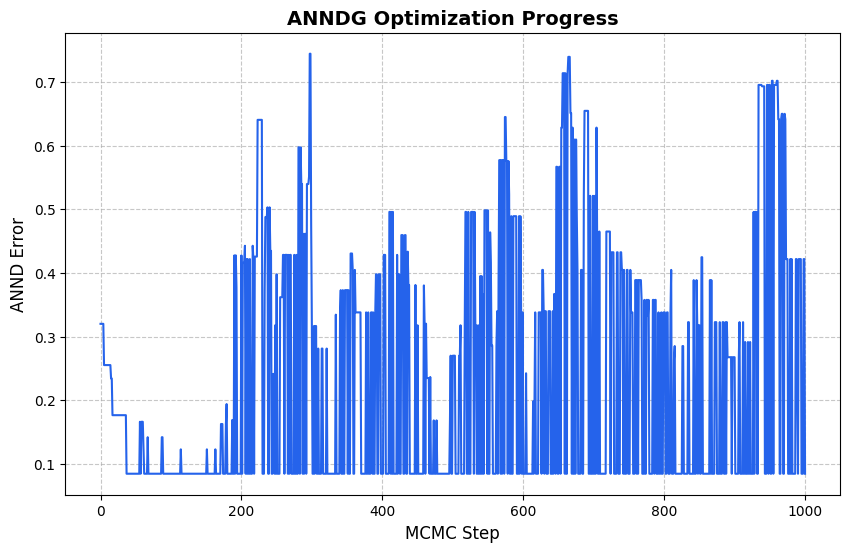

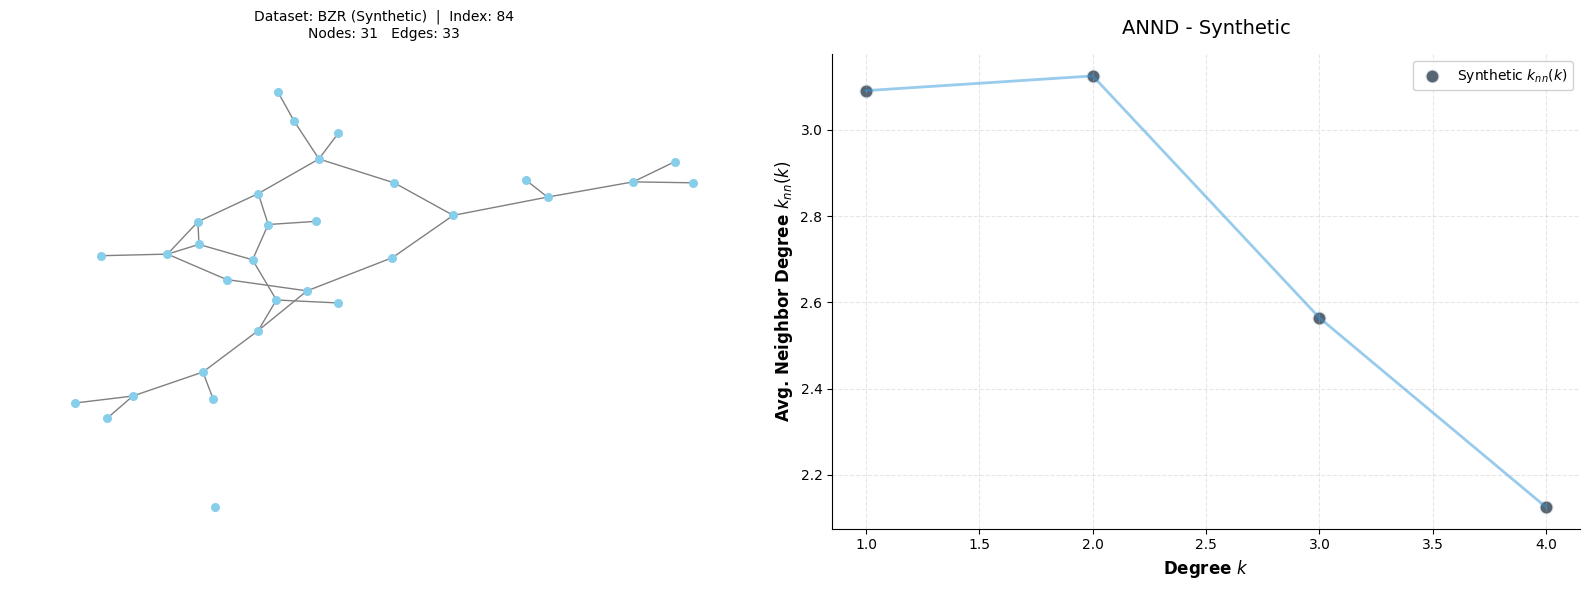


STRUCTURAL ERROR ANALYSIS
ANND Structural Error (Synthetic vs Anndg): 0.0821
Anndg Assortativity:  -0.2862
Synthetic Assortativity: -0.3291


In [13]:
# Prepare target statistics
ig_graph = networkx_to_igraph(GRAPH)
target_stats = {
    "n_nodes": GRAPH.number_of_nodes(),
    "n_edges": GRAPH.number_of_edges(),
    "normalized_degree_moments": count_deg_moments(ig_graph).tolist(),
    "annd": calculate_annd(ig_graph).tolist()
}

# Generate synthetic graph
rng = np.random.default_rng(seed=42)
GRAPH_SYNTH = generate_graph(target_stats, method=METHOD, rng=None)

# Plot synthetic results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_graph(graph=GRAPH_SYNTH, ax=ax1, dataset_name=f"{DATASET} (Synthetic)", graph_index=IDX)
plot_annd(graph=GRAPH_SYNTH, ax=ax2, title=f"ANND - Synthetic", label='Synthetic $k_{nn}(k)$')

# Calculate and print assortativity
assortativity_synth = nx.degree_assortativity_coefficient(GRAPH_SYNTH)

plt.tight_layout()
plt.show()

print("\n" + "="*30)
print("STRUCTURAL ERROR ANALYSIS")
print("="*30)

# Convert to igraph for detailed topological analysis
ig_original = networkx_to_igraph(GRAPH)
ig_synthetic = networkx_to_igraph(GRAPH_SYNTH)

# Calculate ANND and degree sequences for both graphs
annd_original = calculate_annd(ig_original)
deg_seq_original = np.array(ig_original.degree())

annd_synthetic = calculate_annd(ig_synthetic)
deg_seq_synthetic = np.array(ig_synthetic.degree())

# Compute the structural error between the ANND of the synthetic and original graphs
annd_error = calculate_annd_error(
    obtained_annd=annd_synthetic, 
    obtained_degree_sequence=deg_seq_synthetic, 
    target_annd=annd_original, 
    target_degree_sequence=deg_seq_original
)

print(f"ANND Structural Error (Synthetic vs {METHOD.capitalize()}): {annd_error:.4f}")
print(f"{METHOD.capitalize()} Assortativity:  {assortativity:.4f}")
print(f"Synthetic Assortativity: {assortativity_synth:.4f}")
print("="*30)